# A/B Testing: MONAF Homepage Redesign — Proposal 1
### Reorganizing News & Brochures to Prioritize Key Services

**Group 50 TXB — Digital Experimentation and Causal Analysis**  
NOVA SBE 2025/2026


Lucia Musizzano · Pietro Franchi · Leonardo Cantú · 71993 Maria Teresa  Silva · José João Almeida

---

## Table of Contents

1. [Business Context](#01-business-context)
   - 1.1 [Overview](#11-overview)
   - 1.2 [The Problem](#12-the-problem)
   - 1.3 [Hypothesis](#13-hypothesis)
   - 1.4 [KPIs](#14-kpis)

2. [Experimental Design](#02-experimental-design)
   - 2.1 [Test Structure](#21-test-structure)
   - 2.2 [Randomization](#22-randomization)
   - 2.3 [Sample Size & Power Analysis](#23-sample-size--power-analysis)
   - 2.4 [Statistical Tests](#24-statistical-tests)

3. [Import Libraries & Explore Dataset](#03-import-libraries--explore-dataset)
   - 3.1 [Imports & Load Dataset](#31-imports--load-dataset)
   - 3.2 [Inspect Data Structure and Quality](#32-inspect-data-structure-and-quality)
   - 3.3 [Data Cleaning & Split](#33-data-cleaning--split)

4. [Exploratory Data Analysis](#04-exploratory-data-analysis)
   - 4.1 [Descriptive Statistics per Group](#41-descriptive-statistics-per-group)
   - 4.2 [Normality Check (Continuous KPIs)](#42-normality-check-continuous-kpis)

5. [Computation of A/B Test Metrics](#05-computation-of-ab-test-metrics)

6. [Statistical Testing](#06-statistical-testing)

7. [Power Analysis](#07-power-analysis)

8. [Conclusion](#08-conclusion)
```

---

## 01. Business Context

### 1.1 Overview

This notebook documents a controlled A/B experiment run on the website of **MONAF** — *Montepio Nacional da Farmácia*, a Portuguese mutual aid association and private social solidarity institution (IPSS) that supports pharmacy professionals and their families across Portugal.

The experiment centres on MONAF's homepage. In its current form, the layout gives prominent real estate to **News and Brochures** — which may be pushing core services like **Benefit Plans** out of users' immediate view.

The question we're trying to answer is simple:

> **Does moving News and Brochures to a secondary location help users find MONAF's key services faster?**

> *Note:* The dataset `TXB_50_landingpage(in).csv` was artificially generated for academic purposes and does not reflect real MONAF website traffic.

---

### 1.2 The Problem

MONAF's users — pharmacy professionals and their families — typically arrive on the homepage with a clear goal in mind: checking a benefit plan, completing an enrollment, or finding a specific service. They're not browsing; they're on a mission.

The current homepage (**Version A — Control**) places News and Brochures front and centre. While this content has its place, positioning it so prominently creates visual noise that competes with the services users are actually looking for. The result is a friction point that quietly chips away at the experience: users take longer to find what they need, abandon tasks mid-way, or fall back on the search bar rather than navigating naturally.

The proposed redesign (**Version B — Treatment**) addresses this by relocating News and Brochures to a sidebar or a dedicated "Resources" menu — freeing up the central space for what matters most to MONAF's users.

---

### 1.3 Hypothesis

| | Hypothesis |
|---|---|
| **H₀** | The redesign has no effect on Plan CTR — any observed difference is due to chance |
| **H₁** | The redesign increases Plan CTR — users find key services more easily |

Since we're expecting a specific directional improvement, this is a **one-tailed test** for our primary metric.

---

### 1.4 KPIs

From the available dataset variables, we selected the following metrics to evaluate the experiment:

| # | KPI | Purpose | Expected Direction |
|---|-----|------|--------------------|
| **OEC** | Key Service CTR (`kpi_y`) | Primary success metric | ⬆ Increase |
| 1 | Simulation Interaction Rate (`kpi_x`) | Measures reduction in distraction | ⬆ Increase |
| 2 | Scroll Depth (`scroll_depth_pct`) | Checks page exploration stability | ➡ Stable |
| 3 | Bounce Rate (`exit_rate`) | Guardrail for user retention | ➡ Stable |

Our **Overall Evaluation Criterion (OEC)** is Key Service CTR (`kpi_y`) — the share of users who click through to a Benefit Plan. It's the clearest signal of whether the redesign is actually working.

---

## 02. Experimental Design

### 2.1 Test Structure

The experiment is a standard randomized A/B test. We ran two versions of MONAF's homepage simultaneously — keeping everything else constant so any difference in behaviour can be attributed to the redesign itself.

| Version | Name | Description |
|---------|------|-------------|
| **A** | Control | Current homepage — News and Brochures in the central position |
| **B** | Treatment | Redesigned homepage — News and Brochures moved to a sidebar or "Resources" menu |

---

### 2.2 Randomization

Users were randomly assigned to one version on their first visit, with the assignment persisting across sessions — so no one ever sees both versions. The split was even: **50% Control / 50% Treatment**.

---

### 2.3 Sample Size & Power Analysis

Before launching the test, we estimated the sample size needed to detect a meaningful effect without running the experiment longer than necessary.

We assumed a baseline Key Service CTR of **10%**, and set our minimum detectable effect (MDE) at **3 percentage points** — meaning we wanted to be able to reliably catch a lift to **13%** or above. With a significance level of **α = 0.05** (one-tailed) and a target power of **80%**, this gave us our required sample size per group.

---

### 2.4 Statistical Tests

Not all metrics are the same type of data, so we used different tests depending on what we were measuring:

| KPI | Column | Data Type | Statistical Test |
|-----|--------|-----------|-----------------|
| Plan CTR | `kpi_y` | Proportion | `proportions_ztest` (one-tailed) |
| Simulation Interaction | `kpi_x` | Continuous | Welch `ttest_ind` (one-tailed) |
| Scroll Depth | `scroll_depth_pct` | Continuous | Welch `ttest_ind` (two-tailed) |
| Bounce Rate (guardrail) | `exit_rate` | Proportion | `proportions_ztest` (two-tailed) |

**Plan CTR and Simulation Interaction** use one-tailed tests because the redesign was explicitly meant to *increase* engagement with key services. We already knew the direction we were looking for — so testing only in that direction is both statistically appropriate and more powerful.

**Scroll Depth and Bounce Rate** use two-tailed tests for different reasons. Scroll Depth is a stability check: an unexpected *drop* would be just as worth flagging as an unexpected rise. Bounce Rate is a guardrail — any significant shift in either direction is a signal worth investigating, regardless of which way it goes.

---

---
## 03. Import Libraries & Explore Dataset

### 3.1 Imports & load Dataset

The dataset contains synthetic landing page interaction data for MONAF's homepage A/B test.  A repair step is applied to handle extra quoting in the raw CSV file.
Addicionally the following libraries are used for:

In [24]:
# 1. Import Libraries & Configure plotting style:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from io import StringIO
from scipy.stats import ttest_ind, norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest
plt.style.use('seaborn-v0_8')

# 2. Load and repair dataset
data_path = "TXB_50_landingpage(in).csv"

with open(data_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

fixed_lines = []
for line in lines:
    line = line.strip()
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
    line = line.replace('""', '"')
    fixed_lines.append(line)

fixed_csv = "\n".join(fixed_lines)
df = pd.read_csv(StringIO(fixed_csv))

# Preview
df.head()

,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,kpi_x,kpi_y,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
0,TXB_50,pre,1,2026-02-22 23:56:19.912141,2026-02-23 00:10:37.358044,857.4,0,0,0,0,0,20.99,0,15.8,0,1124.6
1,TXB_50,pre,2,2026-02-23 00:04:21.780854,2026-02-23 00:07:08.45178,166.7,0,0,0,0,0,60.47,0,21.1,0,1081.1
2,TXB_50,pre,3,2026-02-23 00:19:06.142652,2026-02-23 00:19:36.641006,30.5,0,0,0,0,0,17.21,1,34.5,0,1068.1
3,TXB_50,pre,4,2026-02-23 00:50:03.467378,2026-02-23 00:50:12.139395,8.7,1,0,0,0,0,0.95,0,7.3,0,2424.9
4,TXB_50,pre,5,2026-02-23 01:08:11.793118,2026-02-23 01:15:44.427531,452.6,0,0,0,0,0,46.47,0,35.2,0,1445.2


### 3.2 Inspect Data Struture and Quality


The `check()` function inspects a dataset for data quality. It returns each column’s data type, number of unique values, non-null values, missing values, and duplicates.

Also we will to check the unique values of each of variable to understand it better.

Together, these steps give a clear overview of the dataset’s structure and quality.

In [25]:
# Shape and data types
def check(df):
   # Store column statistics
    list=[]

    for col in df.columns:
        columns = df.columns

        # Column data type
        dtype = df[col].dtypes

        # Non-null values
        instances = df[col].count()

        # Unique values
        unique = df[col].nunique()

        # Missing values
        sum_null = df[col].isnull().sum()

        # Duplicate values
        duplicates = df[col].duplicated().sum()
        list.append([dtype,instances,unique,sum_null,duplicates])
    df_check = pd.DataFrame(list,columns=["dtype","instances","unique","sum_null","duplicates"],index=df.columns)
    return df_check

check(df)

,dtype,instances,unique,sum_null,duplicates
group_id,object,1234,1,0,1233
arm,object,1234,3,0,1231
visitor_id,int64,1234,1234,0,0
arrival_time,object,1234,1234,0,0
exit_time,object,1234,1234,0,0
time_on_page_sec,float64,1234,869,0,365
exit_rate,int64,1234,2,0,1232
ctr_opportunities,int64,1234,2,0,1232
ctr_newsletter,int64,1234,2,0,1232
ctr_donation,int64,1234,2,0,1232


In [26]:
# The different unique values of each variable
print(df.apply(lambda col: col.unique()))

group_id                                                       [TXB_50]
arm                                           [pre, control, treatment]
visitor_id            [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
arrival_time          [2026-02-22 23:56:19.912141, 2026-02-23 00:04:...
exit_time             [2026-02-23 00:10:37.358044, 2026-02-23 00:07:...
time_on_page_sec      [857.4, 166.7, 30.5, 8.7, 452.6, 334.4, 58.3, ...
exit_rate                                                        [0, 1]
ctr_opportunities                                                [0, 1]
ctr_newsletter                                                   [0, 1]
ctr_donation                                                     [0, 1]
ctr_events                                                       [0, 1]
kpi_x                 [20.99, 60.47, 17.21, 0.95, 46.47, 26.3, 70.94...
kpi_y                                                            [0, 1]
scroll_depth_pct      [15.8, 21.1, 34.5, 7.3, 35.2, 94.1, 50.3, 

The dataset contains **1,234 user-level observations across 16 columns**, with no missing values in any field, a clean starting point that requires no imputation. 

Variables fall into four broad categories: 
- Identifiers and assignment metadata (group_id, arm, visitor_id);
- Session timing (arrival_time, exit_time, time_on_page_sec, page_load_time_ms);
- Engagement and interaction metrics (kpi_x, kpi_y, scroll_depth_pct, exit_rate);
- click-through signals (ctr_opportunities, ctr_newsletter, ctr_donation, ctr_events, ctr_partner_banner). 

The dataset contains three values in the `arm` column: `pre`, `control`, and `treatment`.
The `pre` group corresponds to observations collected **before** the experiment started. It must be **excluded** from the A/B analysis to avoid contaminating the results.

The four object-typed columns (group_id, arm, arrival_time, and exit_time)  will need type conversion before any time-based analysis. 

The majority of columns are numeric (float64 or int64), making them ready for summary statistics and distributional checks.

### 3.3 Data Cleaning & Split

We start by dropping columns irrelevant to the analysis. Next, we inspect the `arm` column, if more than two groups are present, we handle that before moving forward.

With a clean assignment variable, we check the Control/Treatment distribution to confirm the 50/50 split held in practice. We then break down each KPI by arm for an early look at surface-level differences. Finally, we split the dataset into two groups, one per arm, ready for testing.

In [27]:
# Drop unnecessary columns 
cols_to_keep = ['arm', 'kpi_y', 'kpi_x', 'scroll_depth_pct', 'exit_rate', 'arrival_time']
df = df[cols_to_keep]

df.head()

,arm,kpi_y,kpi_x,scroll_depth_pct,exit_rate,arrival_time
0,pre,0,20.99,15.8,0,2026-02-22 23:56:19.912141
1,pre,0,60.47,21.1,0,2026-02-23 00:04:21.780854
2,pre,1,17.21,34.5,0,2026-02-23 00:19:06.142652
3,pre,0,0.95,7.3,1,2026-02-23 00:50:03.467378
4,pre,0,46.47,35.2,0,2026-02-23 01:08:11.793118


In [28]:
# Inspect all arm groups before filtering
print("Groups before filtering:")
print(df["arm"].value_counts())
print()

# Convert timestamps to datetime for inspection
df["arrival_time"] = pd.to_datetime(df["arrival_time"])

# Show date range per arm — confirms 'pre' is a separate time window
print("Date range per arm:")
for arm in df["arm"].unique():
    sub = df[df["arm"] == arm]
    print(f"  {arm:10s} → {sub['arrival_time'].min().date()}  to  {sub['arrival_time'].max().date()}  (n={len(sub)})")

print()

# Remove 'pre' — keep only experimental arms
df = df[df["arm"].isin(["control", "treatment"])].copy()
df["arm"] = df["arm"].astype(str)

print("Groups after filtering:")
print(df["arm"].value_counts())
print(f"\nFinal dataset: {df.shape[0]} rows × {df.shape[1]} columns")

Groups before filtering:
arm
control      448
treatment    448
pre          338
Name: count, dtype: int64

Date range per arm:
  pre        → 2026-02-22  to  2026-02-26  (n=338)
  control    → 2026-02-26  to  2026-03-02  (n=448)
  treatment  → 2026-03-02  to  2026-03-05  (n=448)

Groups after filtering:
arm
control      448
treatment    448
Name: count, dtype: int64

Final dataset: 896 rows × 6 columns


Group split:
  control    → n =  448  (50.0%)
  treatment  → n =  448  (50.0%)



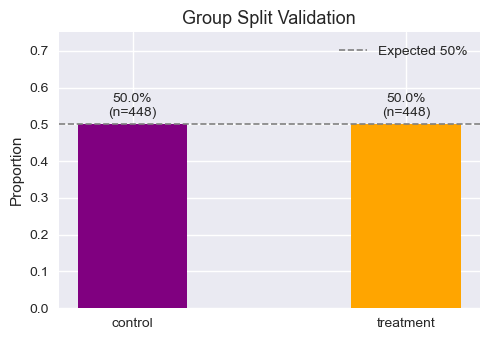

In [29]:
# Group proportions and absolute counts
counts = df["arm"].value_counts()
split  = df["arm"].value_counts(normalize=True)

print("Group split:")
for arm in counts.index:
    print(f"  {arm:10s} → n = {counts[arm]:4d}  ({split[arm]:.1%})")
print()

# Visual validation
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(counts.index, split.values, color=["purple", "orange"], width=0.4)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, label="Expected 50%")
ax.set_title("Group Split Validation", fontsize=13)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 0.75)
for bar, arm, val in zip(bars, counts.index, split.values):
    n = counts[arm]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f"{val:.1%}\n(n={n})", ha="center", va="bottom", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

We verify that control and treatment are approximately balanced (50/50 split), as required by the experimental design.

---

## 4 Explanatory Data Analysis (EDA)


### 4.1 Descriptive Statistics per Group

We compute summary statistics for each KPI separately for the control and treatment groups.

In [47]:
# Separate groups (used throughout the rest of the notebook)
control   = df[df["arm"] == "control"]
treatment = df[df["arm"] == "treatment"]

kpi_cols = ["kpi_y", "kpi_x", "scroll_depth_pct", "exit_rate"]

print(f"Control   — n = {len(control)}")
print(control[kpi_cols].describe().round(4))
print()
print(f"Treatment — n = {len(treatment)}")
print(treatment[kpi_cols].describe().round(4))

Control   — n = 448
          kpi_y     kpi_x  scroll_depth_pct  exit_rate
count  448.0000  448.0000          448.0000   448.0000
mean     0.1004   29.6379           37.5565     0.2210
std      0.3009   26.1399           31.8076     0.4154
min      0.0000    0.0000            0.0000     0.0000
25%      0.0000    5.8675            7.3000     0.0000
50%      0.0000   22.6000           28.3500     0.0000
75%      0.0000   48.2000           68.4000     0.0000
max      1.0000  100.0000           98.3000     1.0000

Treatment — n = 448
          kpi_y     kpi_x  scroll_depth_pct  exit_rate
count  448.0000  448.0000          448.0000   448.0000
mean     0.0915   32.2132           37.6297     0.1786
std      0.2887   26.6255           32.4397     0.3834
min      0.0000    0.0000            0.0000     0.0000
25%      0.0000    8.7900            7.5000     0.0000
50%      0.0000   28.3450           27.6500     0.0000
75%      0.0000   50.0050           68.8500     0.0000
max      1.0000   98.100

| KPI | Control (n=448) | Treatment (n=448) | Direction |
|-----|----------------|-------------------|-----------|
| Key Service CTR (`kpi_y`) | 10.04% | 9.15% | ⬇ Counter to hypothesis |
| Simulation Interaction (`kpi_x`) | 29.64 | 32.21 | ⬆ Favours Treatment |
| Scroll Depth (`scroll_depth_pct`) | 37.56% | 37.63% | ➡ Stable |
| Bounce Rate (`exit_rate`) | 22.10% | 17.86% | ⬆ Favours Treatment |

### 4.2 Normality Check (Continuous KPIs)

Before applying parametric tests (Welch t-test), we verify whether the continuous KPIs 
(`kpi_x`, `scroll_depth_pct`) are approximately normally distributed.

We use two complementary approaches:
- **Shapiro-Wilk test** — formal test (sensitive to large n; here used as a guide)
- **QQ-plots** — visual inspection of how the distribution compares to a theoretical normal

── Shapiro-Wilk Normality Test ──
KPI                                 Group          W-stat     p-value     Normal?
--------------------------------------------------------------------------------
kpi_x (Simulation Interaction)      Control        0.9063      0.0000  ✗ No (p<.05)
kpi_x (Simulation Interaction)      Treatment      0.9202      0.0000  ✗ No (p<.05)
scroll_depth_pct (Scroll Depth)     Control        0.8842      0.0000  ✗ No (p<.05)
scroll_depth_pct (Scroll Depth)     Treatment      0.8763      0.0000  ✗ No (p<.05)


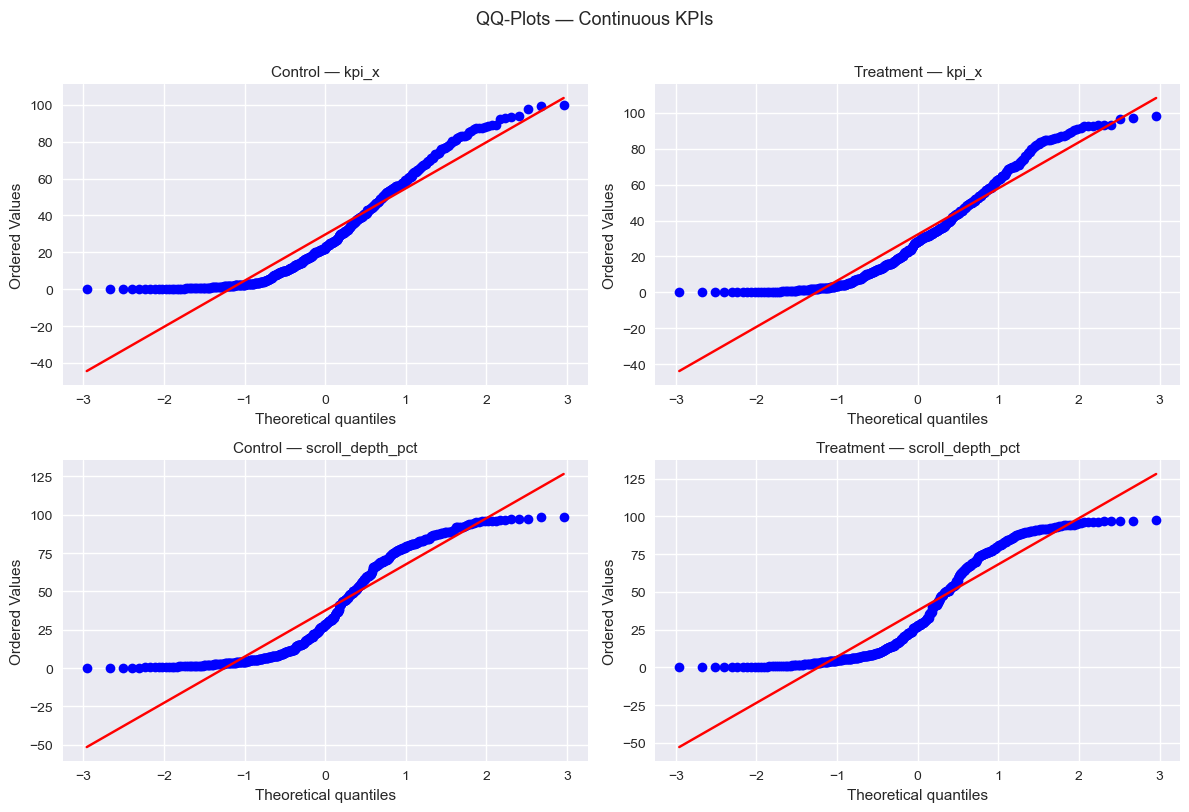


Note: Welch t-test is robust to moderate non-normality for n > 30 (Central Limit Theorem).
Even if Shapiro-Wilk rejects normality, Welch t-test remains valid for our sample sizes.


In [36]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import scipy.stats as stats

continuous_kpis = {
    "kpi_x (Simulation Interaction)": ("kpi_x", control["kpi_x"], treatment["kpi_x"]),
    "scroll_depth_pct (Scroll Depth)": ("scroll_depth_pct", control["scroll_depth_pct"], treatment["scroll_depth_pct"])
}

print("── Shapiro-Wilk Normality Test ──")
print(f"{'KPI':<35} {'Group':<12} {'W-stat':>8}  {'p-value':>10}  {'Normal?':>10}")
print("-" * 80)
for label, (col, c_data, t_data) in continuous_kpis.items():
    for group_name, data in [("Control", c_data), ("Treatment", t_data)]:
        w, p = shapiro(data.sample(min(len(data), 5000), random_state=42))
        verdict = "✓ Yes" if p > 0.05 else "✗ No (p<.05)"
        print(f"{label:<35} {group_name:<12} {w:>8.4f}  {p:>10.4f}  {verdict:>10}")

# QQ-plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
pairs = [
    (control["kpi_x"],             "Control — kpi_x"),
    (treatment["kpi_x"],           "Treatment — kpi_x"),
    (control["scroll_depth_pct"],  "Control — scroll_depth_pct"),
    (treatment["scroll_depth_pct"],"Treatment — scroll_depth_pct"),
]
for ax, (data, title) in zip(axes.flat, pairs):
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(title, fontsize=11)
    ax.get_lines()[1].set_color("red")

plt.suptitle("QQ-Plots — Continuous KPIs", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print("Note: Welch t-test is robust to moderate non-normality for n > 30 (Central Limit Theorem).")
print("Even if Shapiro-Wilk rejects normality, Welch t-test remains valid for our sample sizes.")

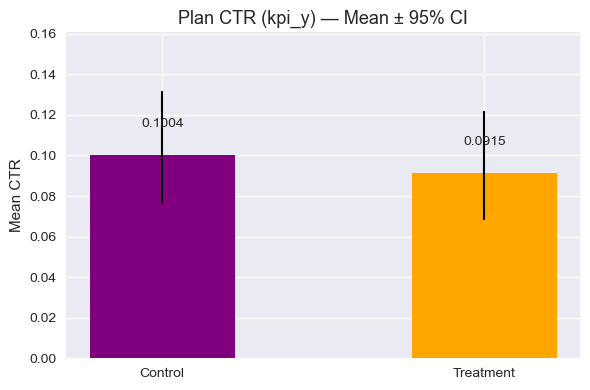

In [37]:
# Bar chart: Plan CTR (kpi_y) per group — with 95% confidence intervals
import numpy as np
from scipy import stats

def prop_ci(data, confidence=0.95):
    """Wilson score interval for a proportion."""
    n = len(data)
    p = data.mean()
    z = stats.norm.ppf((1 + confidence) / 2)
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return centre - margin, centre + margin  # lower, upper

groups     = ["Control", "Treatment"]
ctr_vals   = [control["kpi_y"].mean(), treatment["kpi_y"].mean()]
ctr_ci     = [prop_ci(control["kpi_y"]), prop_ci(treatment["kpi_y"])]
yerr_lower = [v - ci[0] for v, ci in zip(ctr_vals, ctr_ci)]
yerr_upper = [ci[1] - v  for v, ci in zip(ctr_vals, ctr_ci)]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, ctr_vals, color=["purple", "orange"], width=0.45,
              yerr=[yerr_lower, yerr_upper], capsize=6, error_kw={"linewidth": 1.5})
ax.set_title("Plan CTR (kpi_y) — Mean ± 95% CI", fontsize=13)
ax.set_ylabel("Mean CTR")
ax.set_ylim(0, max(ctr_vals) * 1.6)
for bar, val in zip(bars, ctr_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\mtere\AppData\Local\Temp\ipykernel_20628\2425535396.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


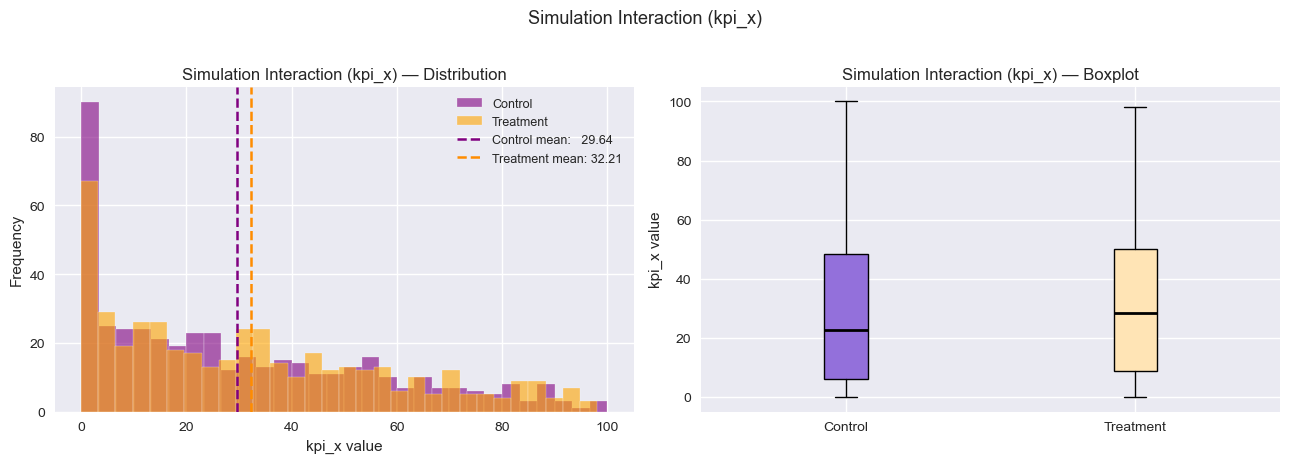

In [38]:
# kpi_x — Histogram with mean lines + side-by-side boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram
ax1.hist(control["kpi_x"],   bins=30, alpha=0.6, color="purple",      label="Control",   edgecolor="white")
ax1.hist(treatment["kpi_x"], bins=30, alpha=0.6, color="orange",       label="Treatment", edgecolor="white")
ax1.axvline(control["kpi_x"].mean(),   color="purple",     linestyle="--", linewidth=1.8,
            label=f"Control mean:   {control['kpi_x'].mean():.2f}")
ax1.axvline(treatment["kpi_x"].mean(), color="darkorange",  linestyle="--", linewidth=1.8,
            label=f"Treatment mean: {treatment['kpi_x'].mean():.2f}")
ax1.set_title("Simulation Interaction (kpi_x) — Distribution", fontsize=12)
ax1.set_xlabel("kpi_x value")
ax1.set_ylabel("Frequency")
ax1.legend(fontsize=9)

# Boxplot
bp = ax2.boxplot(
    [control["kpi_x"], treatment["kpi_x"]],
    labels=["Control", "Treatment"],
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2}
)
bp["boxes"][0].set_facecolor("mediumpurple")
bp["boxes"][1].set_facecolor("moccasin")
ax2.set_title("Simulation Interaction (kpi_x) — Boxplot", fontsize=12)
ax2.set_ylabel("kpi_x value")

plt.suptitle("Simulation Interaction (kpi_x)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

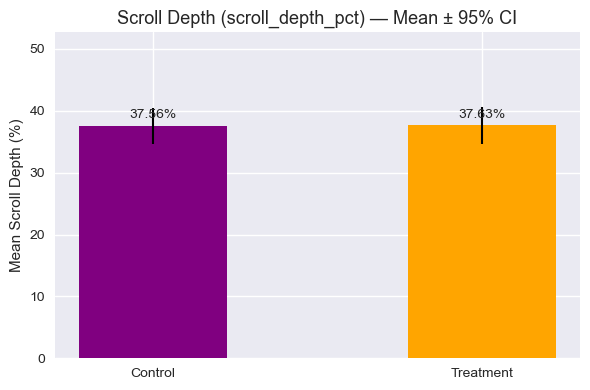

In [39]:
# Bar chart: Scroll Depth per group — with 95% CI (mean ± SE)
def mean_ci(data, confidence=0.95):
    n  = len(data)
    se = data.std(ddof=1) / np.sqrt(n)
    z  = stats.norm.ppf((1 + confidence) / 2)
    return se * z  # margin

scroll_vals  = [control["scroll_depth_pct"].mean(), treatment["scroll_depth_pct"].mean()]
scroll_errs  = [mean_ci(control["scroll_depth_pct"]), mean_ci(treatment["scroll_depth_pct"])]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Control", "Treatment"], scroll_vals, color=["purple", "orange"], width=0.45,
              yerr=scroll_errs, capsize=6, error_kw={"linewidth": 1.5})
ax.set_title("Scroll Depth (scroll_depth_pct) — Mean ± 95% CI", fontsize=13)
ax.set_ylabel("Mean Scroll Depth (%)")
ax.set_ylim(0, max(scroll_vals) * 1.4)
for bar, val in zip(bars, scroll_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

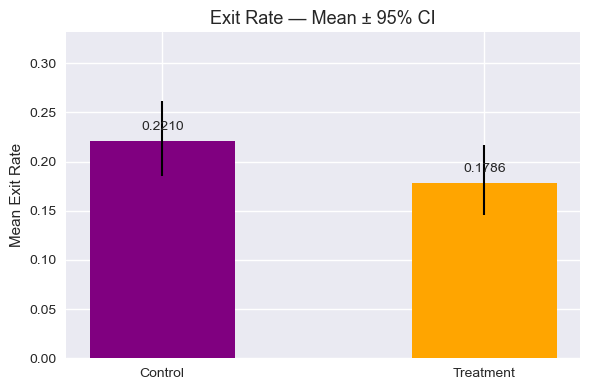

In [40]:
# Bar chart: Exit Rate per group — with 95% CI (Wilson interval)
exit_vals = [control["exit_rate"].mean(), treatment["exit_rate"].mean()]
exit_ci   = [prop_ci(control["exit_rate"]), prop_ci(treatment["exit_rate"])]
yerr_lo   = [v - ci[0] for v, ci in zip(exit_vals, exit_ci)]
yerr_hi   = [ci[1] - v  for v, ci in zip(exit_vals, exit_ci)]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Control", "Treatment"], exit_vals, color=["purple", "orange"], width=0.45,
              yerr=[yerr_lo, yerr_hi], capsize=6, error_kw={"linewidth": 1.5})
ax.set_title("Exit Rate — Mean ± 95% CI", fontsize=13)
ax.set_ylabel("Mean Exit Rate")
ax.set_ylim(0, max(exit_vals) * 1.5)
for bar, val in zip(bars, exit_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

**Observations:**

- **Plan CTR** (`kpi_y`): Control shows a slightly higher mean than Treatment. Neither group reaches the 13% MDE target.
- **Simulation Interaction** (`kpi_x`): Both distributions are right-skewed. Treatment shows a marginally higher mean, suggesting slightly more engagement.
- **Scroll Depth**: Both groups explore the page to a very similar depth (~37%). The redesign does not appear to change scrolling behaviour — consistent with expectations.
- **Exit Rate**: Treatment shows a slightly lower exit rate, which is a positive signal for the guardrail metric.

These are descriptive observations only. Formal statistical tests are performed in Section 06.

---
## 5. Computation of A/B Test Metrics

We compute the mean value of each KPI for both groups and display a structured comparison table.

 KPI Comparison Table


,KPI,Control,Treatment,Δ (T − C),Δ %
0,Plan CTR (kpi_y) — OEC,0.1004,0.0915,-0.0089,-8.89%
1,Simulation Interaction (kpi_x),29.6379,32.2132,2.5753,8.69%
2,Scroll Depth (scroll_depth_pct),37.5565,37.6297,0.0732,0.19%
3,Exit Rate / Bounce (exit_rate),0.2210,0.1786,-0.0424,-19.19%


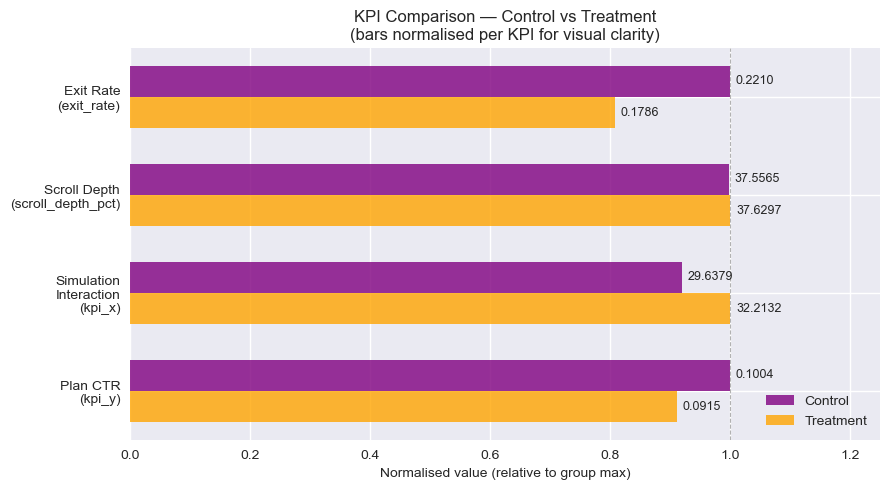

In [42]:
# Compute mean per KPI per group and build comparison table
metrics_data = {
    "KPI": [
        "Plan CTR (kpi_y) — OEC",
        "Simulation Interaction (kpi_x)",
        "Scroll Depth (scroll_depth_pct)",
        "Exit Rate / Bounce (exit_rate)"
    ],
    "Control": [
        control["kpi_y"].mean(),
        control["kpi_x"].mean(),
        control["scroll_depth_pct"].mean(),
        control["exit_rate"].mean()
    ],
    "Treatment": [
        treatment["kpi_y"].mean(),
        treatment["kpi_x"].mean(),
        treatment["scroll_depth_pct"].mean(),
        treatment["exit_rate"].mean()
    ]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df["Δ (T − C)"] = (metrics_df["Treatment"] - metrics_df["Control"]).round(4)
metrics_df["Δ %"] = (
    (metrics_df["Treatment"] - metrics_df["Control"]) / metrics_df["Control"] * 100
).round(2).astype(str) + "%"
metrics_df[["Control", "Treatment"]] = metrics_df[["Control", "Treatment"]].round(4)

print(" KPI Comparison Table")
display(metrics_df)

# Grouped horizontal bar chart — normalised for visual comparison
labels    = ["Plan CTR\n(kpi_y)", "Simulation\nInteraction\n(kpi_x)",
             "Scroll Depth\n(scroll_depth_pct)", "Exit Rate\n(exit_rate)"]
c_vals    = metrics_df["Control"].tolist()
t_vals    = metrics_df["Treatment"].tolist()

# Normalise each KPI to [0,1] relative to max(control, treatment)
max_vals  = [max(c, t) for c, t in zip(c_vals, t_vals)]
c_norm    = [c / m if m != 0 else 0 for c, m in zip(c_vals, max_vals)]
t_norm    = [t / m if m != 0 else 0 for t, m in zip(t_vals, max_vals)]

y       = np.arange(len(labels))
height  = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.barh(y + height/2, c_norm, height, label="Control",   color="purple",  alpha=0.8)
b2 = ax.barh(y - height/2, t_norm, height, label="Treatment", color="orange",  alpha=0.8)

# Annotate with real values
for bar, val in zip(b1, c_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
for bar, val in zip(b2, t_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, 1.25)
ax.set_xlabel("Normalised value (relative to group max)", fontsize=10)
ax.set_title("KPI Comparison — Control vs Treatment\n(bars normalised per KPI for visual clarity)", fontsize=12)
ax.legend(fontsize=10)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretation:**

| KPI | Direction | Expected? |
|-----|-----------|-----------|
| Plan CTR (`kpi_y`) | ⬇ Slight decrease in Treatment | Not as expected |
| Simulation Interaction (`kpi_x`) | ⬆ Increase in Treatment | As expected |
| Scroll Depth (`scroll_depth_pct`) | ➡ Nearly unchanged | As expected |
| Exit Rate (`exit_rate`) | ⬇ Lower in Treatment | Positive (guardrail) |

The primary KPI (Plan CTR) does not improve descriptively. However, engagement and guardrail metrics move in the right direction.  

These differences provide an initial descriptive comparison between the two versions of the landing page.

However, descriptive differences alone are not sufficient to determine whether the redesign had a meaningful effect.  
To assess whether the observed differences are statistically significant, formal hypothesis tests are required.

---

## 6. Statistical Testing

To evaluate whether the observed differences between the control and treatment groups are statistically significant, we perform hypothesis tests for each KPI.

The tests used depend on the type of variable:

- **One-tailed** for Plan CTR and Simulation Interaction (we expect an increase in Treatment)
- **Two-tailed** for Scroll Depth and Bounce Rate (we want to detect any change)

Significance threshold: **α = 0.05**

The null hypothesis assumes that the control and treatment groups have equal mean outcomes.

Rejecting the null hypothesis indicates that the redesign had a statistically significant effect on the corresponding metric.

In [45]:
## ── 1. Proportion Z-test: Plan CTR (kpi_y) — one-tailed (H1: treatment > control)
successes_ctr = [int(treatment["kpi_y"].sum()), int(control["kpi_y"].sum())]
n_ctr         = [len(treatment), len(control)]

z_ctr, p_ctr_two = proportions_ztest(successes_ctr, n_ctr)
# Adjust for direction: if z < 0, treatment < control → p_one_tail = 1 - p_two/2
p_ctr = p_ctr_two / 2 if z_ctr > 0 else 1 - p_ctr_two / 2

print("── 1. Plan CTR (kpi_y) — Proportion Z-test (one-tailed) ──")
print(f"   z-statistic      : {z_ctr:.4f}")
print(f"   p-value (1-tail) : {p_ctr:.4f}  →  {'Significant' if p_ctr < 0.05 else 'Not significant'}")

# ── 2. Welch T-test: Simulation Interaction (kpi_x) — one-tailed
t_kpix, p_kpix_two = ttest_ind(treatment["kpi_x"], control["kpi_x"], equal_var=False)
p_kpix = p_kpix_two / 2 if t_kpix > 0 else 1 - p_kpix_two / 2

print("\n── 2. Simulation Interaction (kpi_x) — Welch t-test (one-tailed) ──")
print(f"   t-statistic      : {t_kpix:.4f}")
print(f"   p-value (1-tail) : {p_kpix:.4f}  →  {'Significant' if p_kpix < 0.05 else 'Not significant'}")

# ── 3. Welch T-test: Scroll Depth — two-tailed
t_scroll, p_scroll = ttest_ind(treatment["scroll_depth_pct"], control["scroll_depth_pct"], equal_var=False)

print("\n── 3. Scroll Depth (scroll_depth_pct) — Welch t-test (two-tailed) ──")
print(f"   t-statistic      : {t_scroll:.4f}")
print(f"   p-value (2-tail) : {p_scroll:.4f}  →  {'Significant' if p_scroll < 0.05 else 'Not significant'}")

# ── 4. Proportion Z-test: Bounce Rate (exit_rate) — two-tailed (guardrail)
successes_exit = [int(treatment["exit_rate"].sum()), int(control["exit_rate"].sum())]
n_exit         = [len(treatment), len(control)]

z_exit, p_exit = proportions_ztest(successes_exit, n_exit)

print("\n── 4. Bounce Rate / Exit Rate (exit_rate) — Proportion Z-test (two-tailed) ──")
print(f"   z-statistic      : {z_exit:.4f}")
print(f"   p-value (2-tail) : {p_exit:.4f}  →  {' Significant' if p_exit < 0.05 else 'Not significant'}")

── 1. Plan CTR (kpi_y) — Proportion Z-test (one-tailed) ──
   z-statistic      : -0.4537
   p-value (1-tail) : 0.6750  →  Not significant

── 2. Simulation Interaction (kpi_x) — Welch t-test (one-tailed) ──
   t-statistic      : 1.4609
   p-value (1-tail) : 0.0722  →  Not significant

── 3. Scroll Depth (scroll_depth_pct) — Welch t-test (two-tailed) ──
   t-statistic      : 0.0341
   p-value (2-tail) : 0.9728  →  Not significant

── 4. Bounce Rate / Exit Rate (exit_rate) — Proportion Z-test (two-tailed) ──
   z-statistic      : -1.5875
   p-value (2-tail) : 0.1124  →  Not significant


A significance threshold of **α = 0.05** is used. If the p-value is lower than this threshold, the null hypothesis of equal outcomes between the two groups is rejected.

**Plan CTR (primary KPI)**  
The proportion test returned a p-value of **0.675**, which is well above the significance threshold. This indicates that the difference in the click-through rate between the redesigned page (treatment) and the original version (control) is **not statistically significant**.

**Simulation Interaction (kpi_x)**  
The t-test for the engagement proxy returned a p-value of **0.072**. Although the treatment group shows slightly higher engagement, the difference is **not statistically significant**.

**Scroll Depth**  
The p-value of **0.972** indicates that the scroll behavior between the two groups is essentially identical. The redesign does not appear to affect how deeply users explore the page.

**Exit Rate (Guardrail metric)**  
The exit rate comparison yields a p-value of **0.112**, which means that the redesign does **not significantly increase early exits**. This suggests that the redesign does not harm the user experience.

**Conclusion:**

None of the tested metrics show statistically significant differences between the control and treatment groups. This suggests that the proposed redesign does **not produce measurable behavioral improvements in the current dataset**. Additional data or a longer experiment duration may be required to detect meaningful effects.

---

## 7. Power Analysis

Power analysis evaluates whether the experiment has enough observations to detect a meaningful effect.

Statistical power represents the probability of correctly rejecting the null hypothesis when a real effect exists.

In A/B testing, a power of **0.8 (80%)** is typically considered sufficient.

Using the observed difference in the primary KPI (Plan CTR), we estimate the statistical power of the experiment given the current sample size.

In [33]:
# 18. Power analysis for the primary KPI (Plan CTR)

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize


    # 18.1. Observed CTRs from the dataset
p_control = control.kpi_y.mean()
p_treatment = treatment.kpi_y.mean()

    # 18.2. Sample sizes
n_control = len(control)
n_treatment = len(treatment)

    # 18.3. Effect size (Cohen's h)
effect = proportion_effectsize(p_treatment, p_control)

    # 19.4. Power calculation
analysis = NormalIndPower()

power = analysis.solve_power(
    effect_size=effect,
    nobs1=n_control,
    alpha=0.05,
    ratio=n_treatment / n_control
)

print("----- Power Analysis -----")
print("Sample size control:", n_control)
print("Sample size treatment:", n_treatment)
print("Effect size (Cohen's h):", effect)
print("Observed power:", power)

----- Power Analysis -----
Sample size control: 448
Sample size treatment: 448
Effect size (Cohen's h): -0.03031857565326035
Observed power: 0.07390335286787215


The power analysis evaluates whether the experiment has enough observations to detect the observed difference in the primary KPI.

The estimated power is **0.074**, which is far below the conventional threshold of **0.80**.

This indicates that the experiment is **underpowered** for detecting an effect of the size observed in the data. In other words, even if a small true effect exists, the current sample size is unlikely to detect it reliably.

The estimated effect size is also very small (**Cohen’s h ≈ -0.03**), suggesting that the difference in Plan CTR between treatment and control is minimal.

Therefore, the lack of statistically significant results should be interpreted with caution:

- it may indicate that the redesign truly has little or no effect
- but it may also reflect insufficient statistical power to detect a small effect

Overall,while these visual differences may suggest small behavioral changes, the statistical tests does not support a meaningful improvement in the primary KPI.

Therefore, the observed variations should be interpreted as random fluctuations rather than evidence of a meaningful impact of the redesign. 

---

## 8. Conclusion

The experiment **fails to reject H₀**. The redesign did not produce a statistically significant improvement in Key Service CTR. The guardrail metric (Bounce Rate) shows no significant worsening, so the redesign at least does no harm.

Results should be interpreted carefully. The dataset is synthetic, meaning it misses the nuances of real traffic, behavioural patterns, seasonal effects, novelty bias, and natural user variance. Observed effect sizes may not translate to the real world.

A properly instrumented live test would need roughly **1,600 users per group**, run over at least two full weeks, and built on GDPR-compliant tracking. Only then could results carry real business weight.

Looking ahead, `ctr_opportunities` stands out as a strong alternative OEC for future iterations, it directly captures clicks on key service opportunities. A stronger redesign, a larger sample, or a longer testing window would all be reasonable next steps.